# Analysis Step
This section performs part of the financial analysis workflow for the Expense Predictor project.


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from expense_predictor.analyzer import (load_data,compute_monthly_totals,detect_large_transactions)
from expense_predictor.recommendations import generate_recommendations
from expense_predictor.predictor import predict_next
from expense_predictor.visualizer import (plot_moving_average, plot_category_breakdown, plot_monthly_trend)
from IPython.display import display

# Define the error handling function

In [24]:
def handle_error(e):
    if isinstance(e, FileNotFoundError):
        print("Error: The required file was not found. Please verify the dataset path.")
    elif isinstance(e, KeyError):
        print(f"Dataset is missing an expected column: {e}")
    elif isinstance(e, ValueError):
        print(f"Data format issue detected: {e}")
    else:
        print(f"Unexpected error occurred: {e}")

# Analysis Step
This section performs part of the financial analysis workflow for the Expense Predictor project.
The code cell below is wrapped with basic error handling to ensure that issues such as missing files,
missing columns, or unexpected runtime errors are handled gracefully.

In [25]:
try:
# Adjust path relative to notebook location
    df = load_data("../data/transactions_2.csv")
    
    df.head()
except Exception as e:
    handle_error(e)


  Rows loaded: 1000

[date]
  ✔  All dates parsed successfully.

[amount]
  ✔  Amount range after cleaning: 2.06 → 2153.07

[category]
  ✔  Unique categories after normalisation: 21
                       date    category  amount
0 2022-01-01 08:07:40+00:00      Health  172.97
1 2022-01-01 11:03:49+00:00    Rent Car   81.16
2 2022-01-01 21:08:19+00:00  Restaurant   77.87


# Analysis Step
This section performs part of the financial analysis workflow for the Expense Predictor project.
The code cell below is wrapped with basic error handling to ensure that issues such as missing files,
missing columns, or unexpected runtime errors are handled gracefully.

In [26]:
try:
    monthly_totals = compute_monthly_totals(df)
    
    display(monthly_totals)
except Exception as e:
    handle_error(e)


date
2022-01-31 00:00:00+00:00    11451.85
2022-02-28 00:00:00+00:00     7493.35
2022-03-31 00:00:00+00:00     9192.80
2022-04-30 00:00:00+00:00     8662.23
2022-05-31 00:00:00+00:00    12571.12
2022-06-30 00:00:00+00:00     9738.49
2022-07-31 00:00:00+00:00     9446.53
2022-08-31 00:00:00+00:00    11871.40
2022-09-30 00:00:00+00:00    13958.72
2022-10-31 00:00:00+00:00    11076.40
2022-11-30 00:00:00+00:00    10508.56
2022-12-31 00:00:00+00:00    13889.01
Freq: ME, Name: amount, dtype: float64

# Analysis Step
This section performs part of the financial analysis workflow for the Expense Predictor project.
The code cell below is wrapped with basic error handling to ensure that issues such as missing files,
missing columns, or unexpected runtime errors are handled gracefully.

In [27]:
try:
    unusual = detect_large_transactions(df)
    display(unusual)
except Exception as e:
    handle_error(e)



[detect_large_transactions]
  Mean: 129.86 | Std: 266.63 | Threshold (z>2.0): 663.13
  45 large transaction(s) detected out of 1000 valid rows.


,date,category,amount,z_score
0,2022-05-29 13:36:07+00:00,Tech,2153.07,7.59
1,2022-11-04 13:59:54+00:00,Tech,2139.68,7.54
2,2022-06-27 10:09:19+00:00,Tech,2078.52,7.31
3,2022-01-03 23:56:40+00:00,Tech,2064.07,7.25
4,2022-09-29 11:54:59+00:00,Tech,1936.08,6.77
5,2022-12-23 13:09:41+00:00,Tech,1782.40,6.20
6,2022-12-16 11:57:58+00:00,Tech,1661.75,5.75
7,2022-09-10 07:28:48+00:00,Tech,1649.43,5.70
8,2022-12-03 08:52:50+00:00,Tech,1623.45,5.60
9,2022-11-10 20:36:07+00:00,Tech,1615.82,5.57


# Analysis Step
This section performs part of the financial analysis workflow for the Expense Predictor project.
The code cell below is wrapped with basic error handling to ensure that issues such as missing files,
missing columns, or unexpected runtime errors are handled gracefully.

In [28]:
try:
    prediction = predict_next(monthly_totals)
    print(f"Predicted next month spending: {prediction:.2f}")
except Exception as e:
    handle_error(e)


Predicted next month spending: 12894.94


# Analysis Step
This section performs part of the financial analysis workflow for the Expense Predictor project.
The code cell below is wrapped with basic error handling to ensure that issues such as missing files,
missing columns, or unexpected runtime errors are handled gracefully.

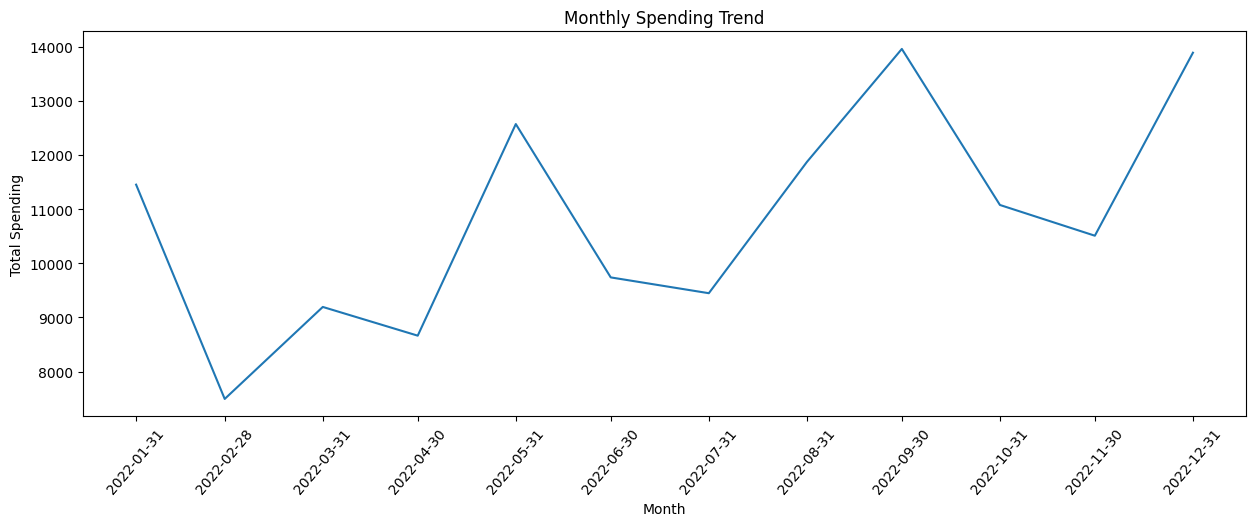

In [29]:
try:
    plt.figure(figsize=[15, 5])
    plt.plot(monthly_totals.index, monthly_totals.values)
    plt.title("Monthly Spending Trend")
    plt.xlabel("Month")
    plt.ylabel("Total Spending")
    plt.xticks(ticks=monthly_totals.index, rotation=50)
    plt.show()
except Exception as e:
    handle_error(e)


# Analysis Step
This section performs part of the financial analysis workflow for the Expense Predictor project.
The code cell below is wrapped with basic error handling to ensure that issues such as missing files,
missing columns, or unexpected runtime errors are handled gracefully.

In [30]:
try:
    recs = generate_recommendations(df)
    for r in recs:
        print("-", r)
except Exception as e:
    handle_error(e)


- You spend the most on 'Tech' ($30317.45). Consider reviewing this category to reduce expenses.
- Your average transaction amount is relatively high. Try to track small purchases more carefully.
- You spend across many categories. Creating a monthly budget could help manage spending.


# Analysis Step
This section performs part of the financial analysis workflow for the Expense Predictor project.
The code cell below is wrapped with basic error handling to ensure that issues such as missing files,
missing columns, or unexpected runtime errors are handled gracefully.

  ✔  All dates parsed successfully.
  ✔  Amount range after cleaning: 2.06 → 2153.07


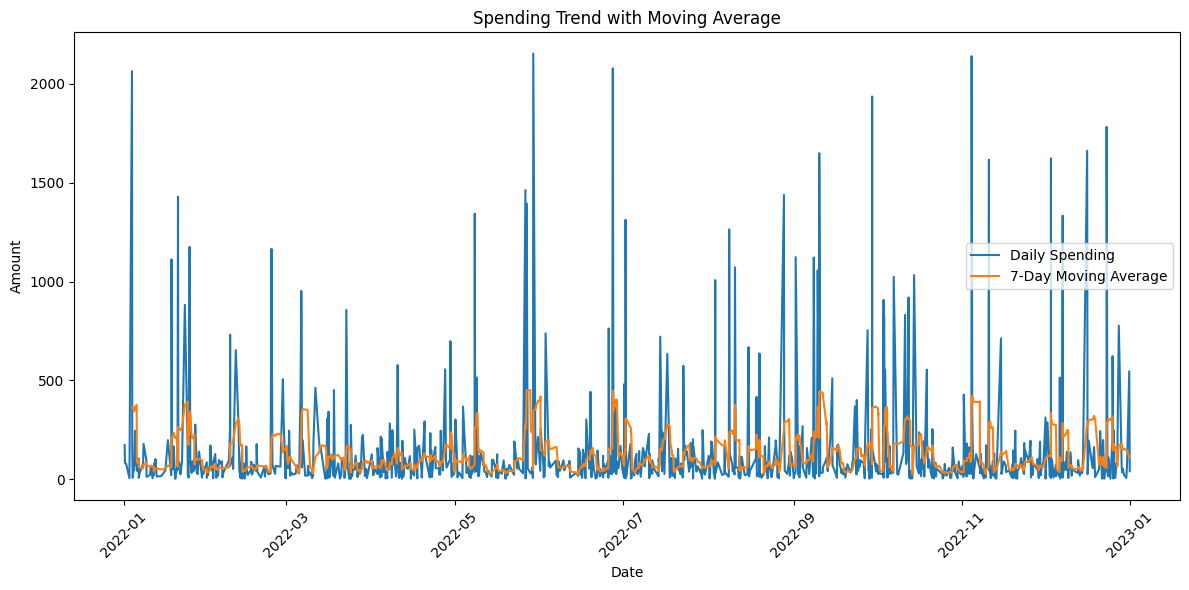

In [31]:
try:
    plot_moving_average("../data/transactions_2.csv")
except Exception as e:
    handle_error(e)


# Analysis Step
This section performs part of the financial analysis workflow for the Expense Predictor project.
The code cell below is wrapped with basic error handling to ensure that issues such as missing files,
missing columns, or unexpected runtime errors are handled gracefully.

  ✔  All dates parsed successfully.
  ✔  Amount range after cleaning: 2.06 → 2153.07


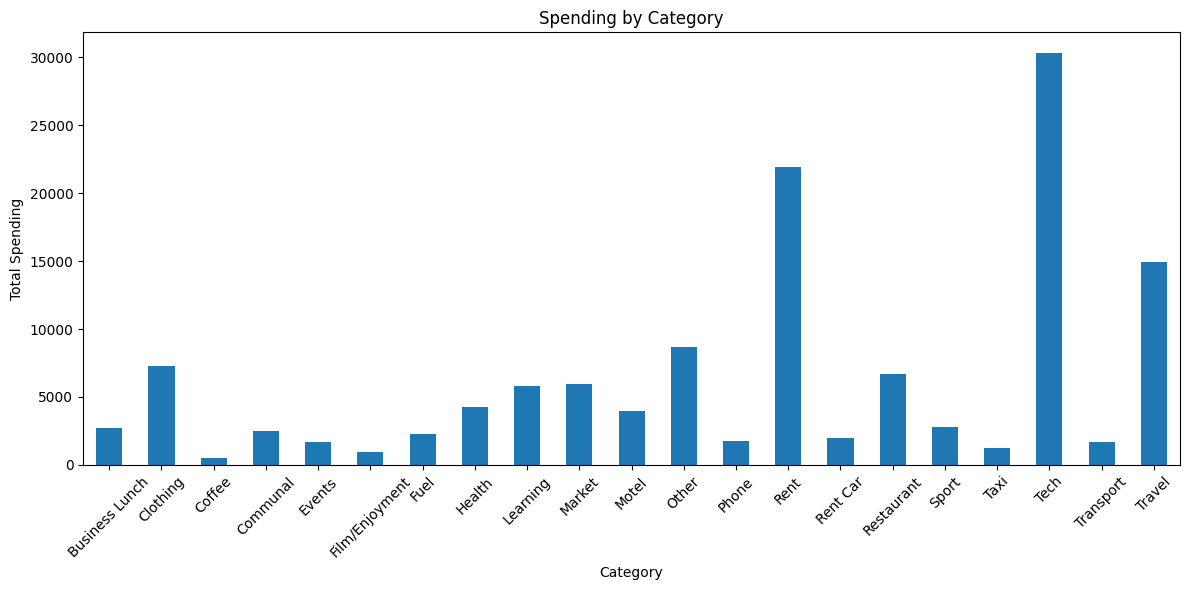

In [32]:
try:
    plot_category_breakdown("../data/transactions_2.csv")
except Exception as e:
    handle_error(e)


# Analysis Step
This section performs part of the financial analysis workflow for the Expense Predictor project.
The code cell below is wrapped with basic error handling to ensure that issues such as missing files,
missing columns, or unexpected runtime errors are handled gracefully.

  ✔  All dates parsed successfully.
  ✔  Amount range after cleaning: 2.06 → 2153.07


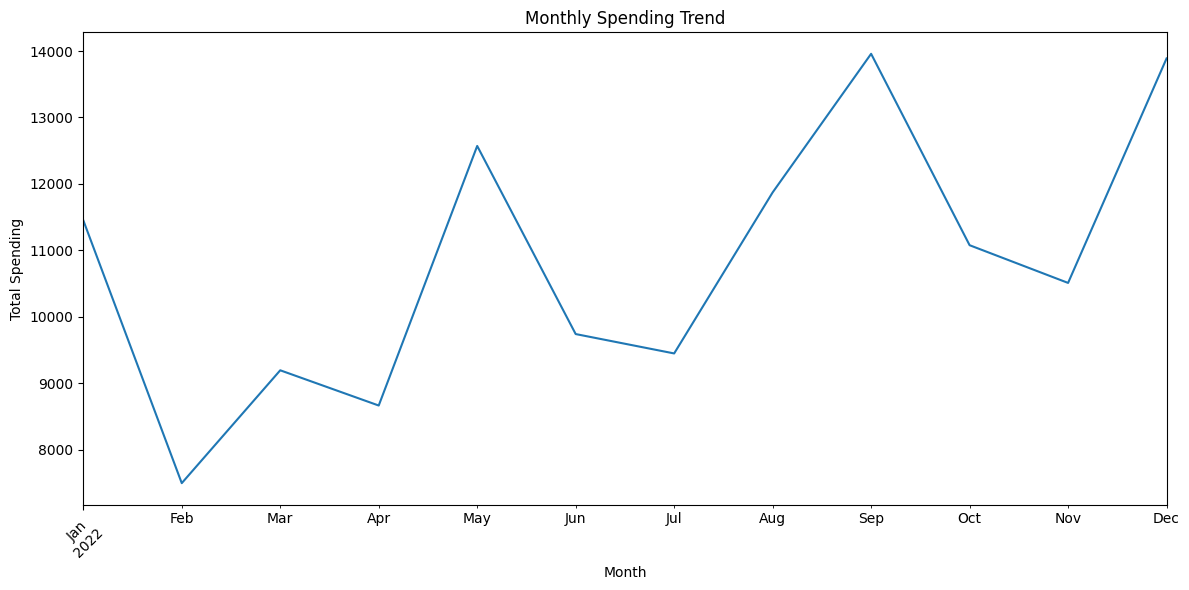

In [33]:
try:
    plot_monthly_trend("../data/transactions_2.csv")
except Exception as e:
    handle_error(e)
